In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00011
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
con

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32.43360652229562
Gradient descend method:  None
RUN  1 , total integrated cost =  9.95268396897004
RUN  2 , total integrated cost =  9.87787997491824
RUN  3 , total integrated cost =  9.86274296635264
RUN  4 , total integrated cost =  9.855931048664
RUN  5 , total integrated cost =  9.851721484071556
RUN  6 , total integrated cost =  9.841061074854728
RUN  7 , total integrated cost =  9.83671995384725
RUN  8 , total integrated cost =  9.836090500239955
RUN  9 , total integrated cost =  9.8349502675505
RUN  10 , total integrated cost =  9.834598786445975
RUN  11 , total integrated cost =  9.834137139536928
RUN  12 , total integrated cost =  9.833886339326787
RUN  13 , total integrated cost =  9.833051634706331
RUN  14 , total integrated cost =  9.832498725850835
RUN  15 , total integrated cost =  9.832423687217556
RUN  16 , total integr

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  55 , total integrated cost =  9.82740397575329
Improved over  55  iterations in  20.273903178051114  seconds by  69.69993463724825  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762274547194 -56.62762266741176
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  98.09262088873636
Gradient descend method:  HS
RUN  1 , total integrated cost =  97.49276080517062
RUN  2 , total integrated cost =  97.44616760568965
RUN  3 , total integrated cost =  97.39241324155536
RUN  4 , total integrated cost =  97.38031316877743
RUN  5 , total integrated cost =  97.2864533319833
RUN  6 , total integrated cost =  97.24873374984811
RUN  7 , total integrated cost =  97.18408666808189
RUN  8 , total integrated cost =  97.11946735171595
RUN  9 , total integrated cost =  97.09765611104915
RUN  10 , total integrated cost =  97.0385373267878
RUN  11 , total integrated cost =  97.03046341167476
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  65 , total integrated cost =  95.83077664939329
Improved over  65  iterations in  11.795167919248343  seconds by  2.305825064974684  percent.
Problem in initial value trasfer:  Vmean_exc -56.627563592156484 -56.627564082384716
weight =  6158.197165679813
set cost params:  1.0 0.0 6158.197165679813
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5879.022004043149
Gradient descend method:  None
RUN  1 , total integrated cost =  5829.626724508095
RUN  2 , total integrated cost =  5829.542413610586
RUN  3 , total integrated cost =  5829.521278681561
RUN  4 , total integrated cost =  5829.413384790185
RUN  5 , total integrated cost =  5829.254136251863
RUN  6 , total integrated cost =  5829.241097912566
RUN  7 , total integrated cost =  5829.0192612906
RUN  8 , total integrated cost =  5828.737477624689
RUN  9 , total integrated cost =  5828.727686141728
RUN  10 , total integrated cost =  5828.478590455529
RUN  11 , total integra

...

RUN  1000 , total integrated cost =  151.5704139870885
RUN  1000 , total integrated cost =  151.5704139870885
Improved over  1000  iterations in  132.13944904506207  seconds by  33.98194527395944  percent.
Problem in initial value trasfer:  Vmean_exc -56.651648466808325 -56.65164857581029
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1515.5101886262178
Gradient descend method:  HS
RUN  1 , total integrated cost =  1514.7591927686915
RUN  2 , total integrated cost =  1514.0329261519419
RUN  3 , total integrated cost =  1513.933891431679
RUN  4 , total integrated cost =  1513.82965408117
RUN  5 , total integrated cost =  1513.7218441759405
RUN  6 , total integrated cost =  1513.3361002163854
RUN  7 , total integrated cost =  1513.0655696065835
RUN  8 , total integrated cost =  1512.9278151923204
RUN  9 , total integrated cost =  1512.815469800041
RUN  10 , total integrated cost =  1512.6920528655523
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  385 , total integrated cost =  1493.151405045475
Improved over  385  iterations in  63.97076113149524  seconds by  1.4753304694711744  percent.
Problem in initial value trasfer:  Vmean_exc -56.65194355728765 -56.65193530634906
weight =  670.0617881565134
set cost params:  1.0 0.0 670.0617881565134
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10001.32477956348
Gradient descend method:  None
RUN  1 , total integrated cost =  9988.182604861244
RUN  2 , total integrated cost =  9986.421743381628
RUN  3 , total integrated cost =  9984.400103544262
RUN  4 , total integrated cost =  9983.355418084635
RUN  5 , total integrated cost =  9982.216278800943
RUN  6 , total integrated cost =  9981.537272239819
RUN  7 , total integrated cost =  9980.845551949904
RUN  8 , total integrated cost =  9980.13708208777
RUN  9 , total integrated cost =  9979.468210863079
RUN  10 , total integrated cost =  9978.787631371464
RUN  11 , total integr

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  5221.710247148244
RUN  1000 , total integrated cost =  5221.710247148244
Improved over  1000  iterations in  171.42703672870994  seconds by  47.789814227229286  percent.
Problem in initial value trasfer:  Vmean_exc -56.651657803611066 -56.65165757091355


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


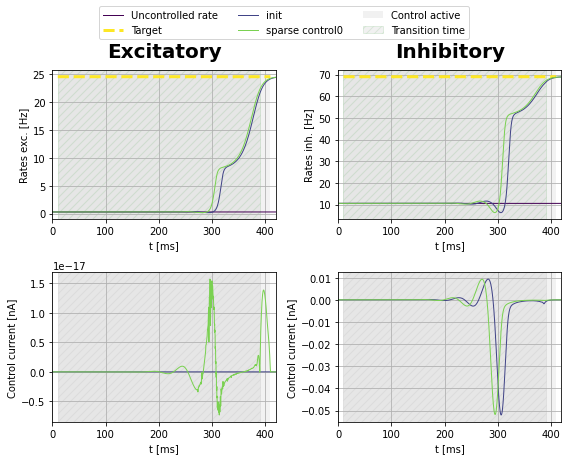

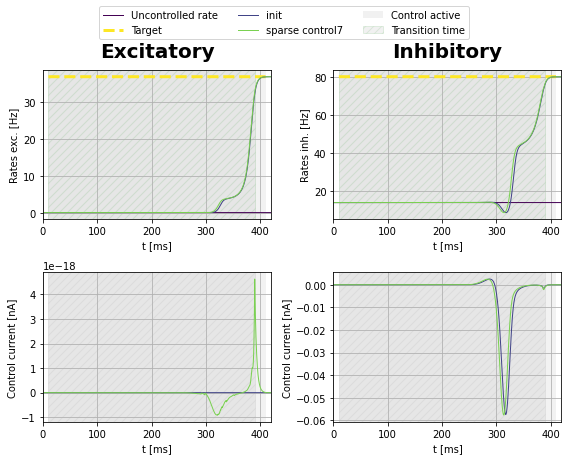

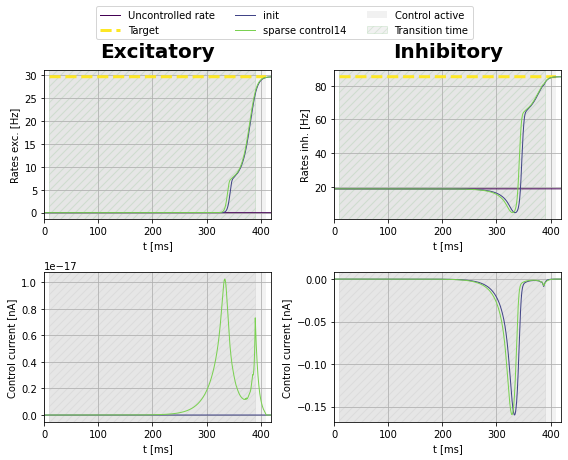

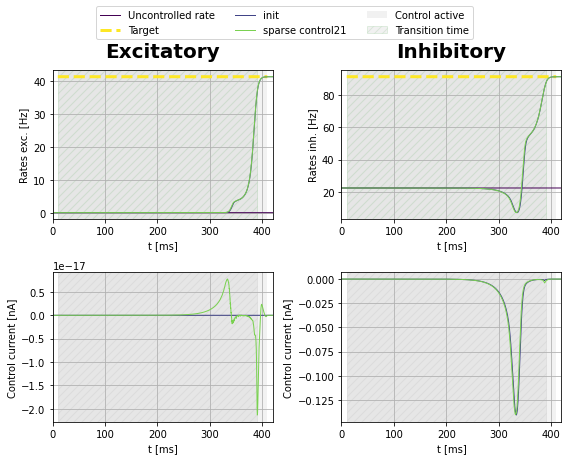

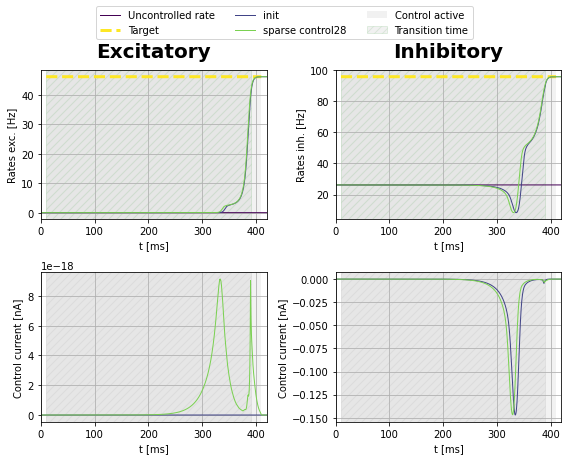

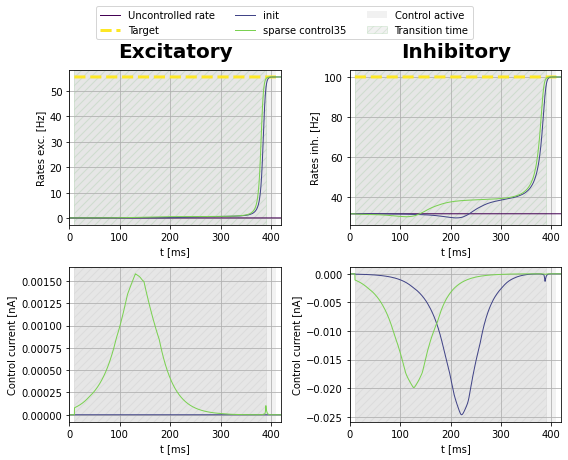

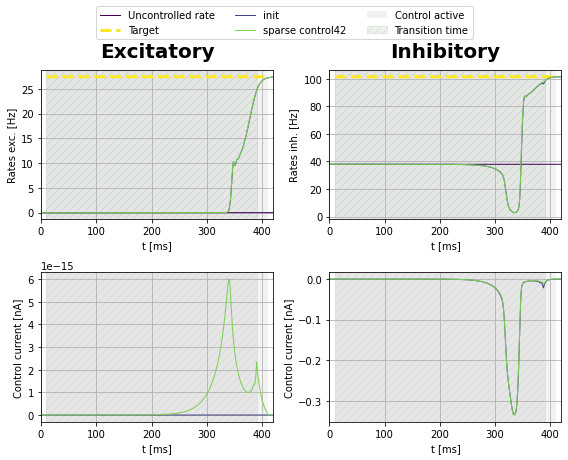

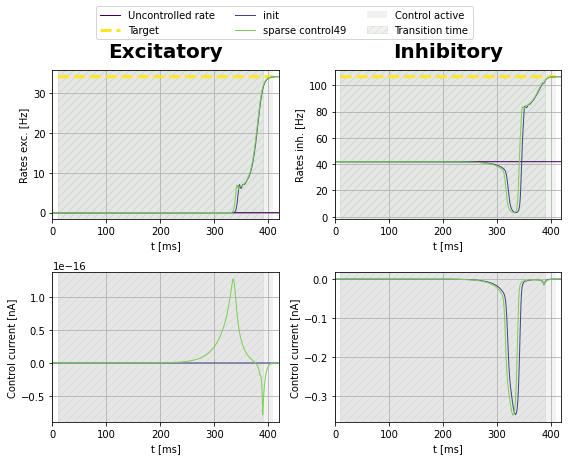

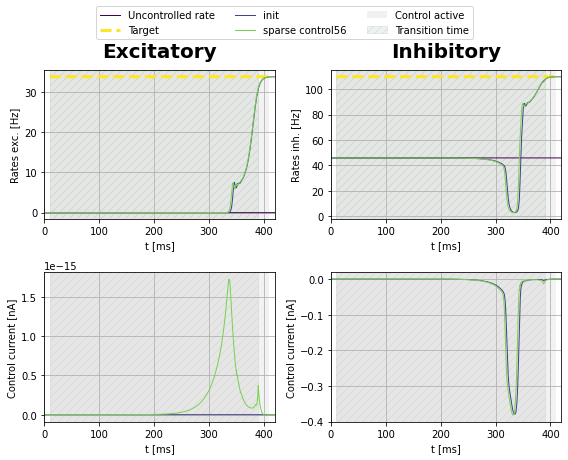

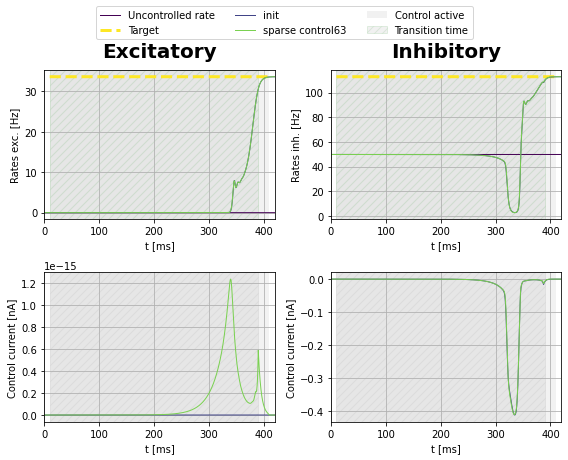

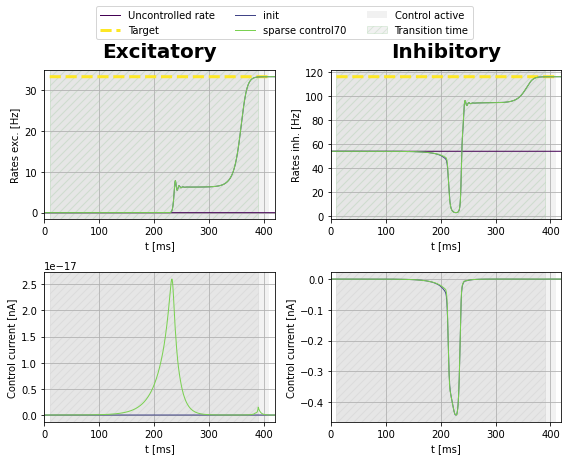

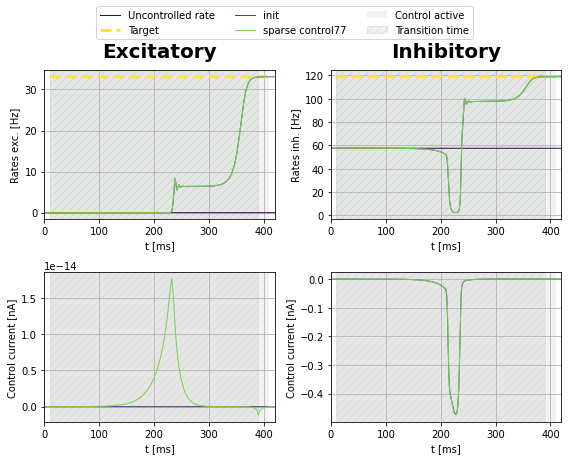

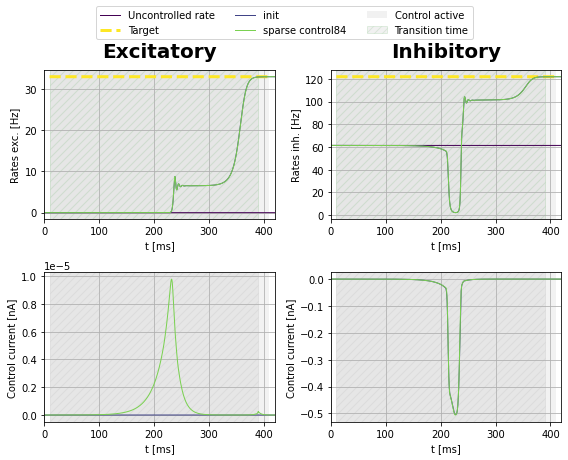

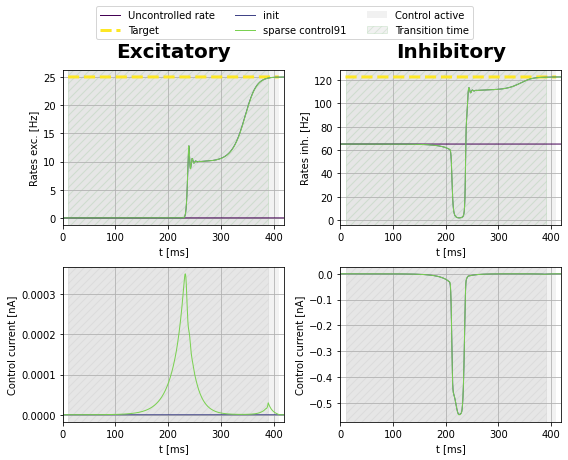

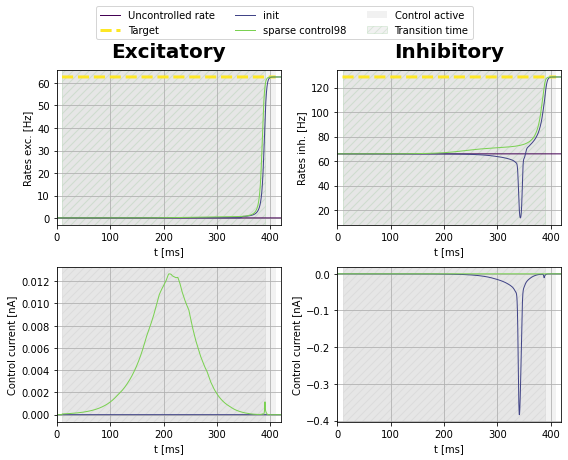

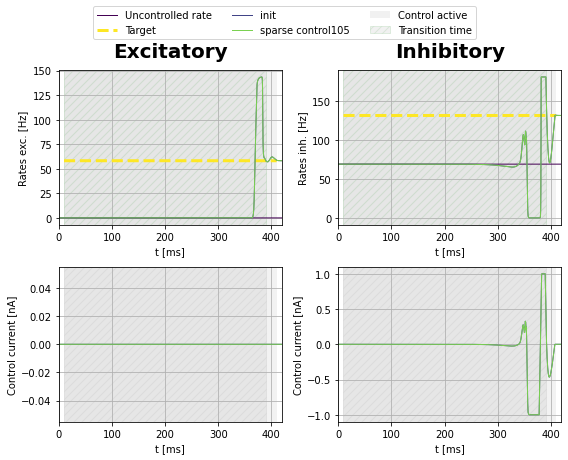

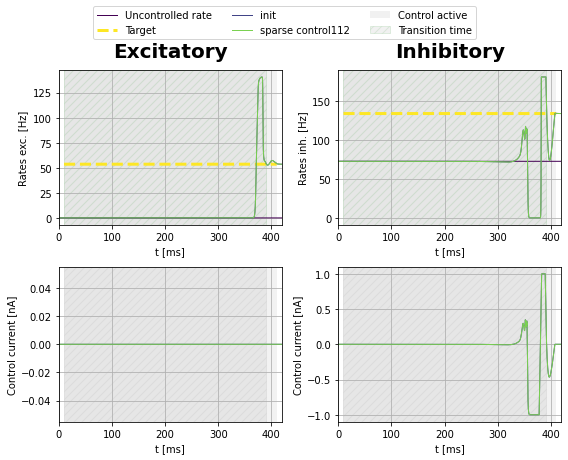

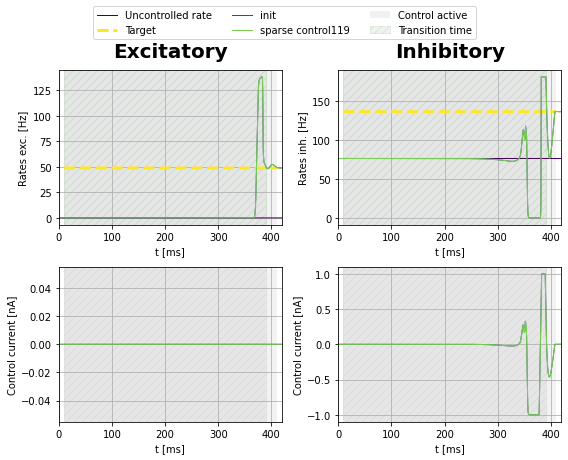

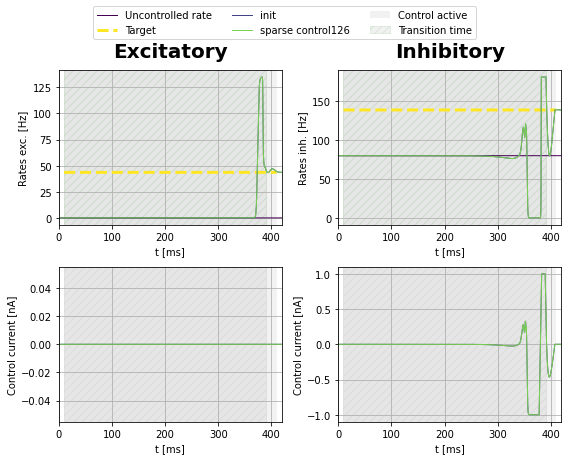

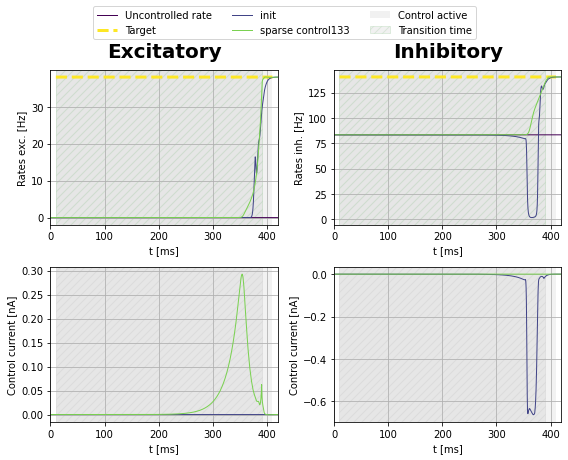

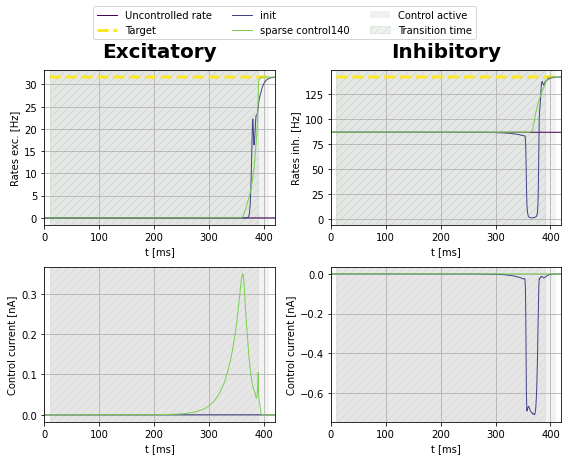

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6240.0435326335455
set cost params:  1.0 0.0 6240.0435326335455
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.288658052633
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.287750198167
RUN  2 , total integrated cost =  5901.28775019815


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  5901.28775019815
Control only changes marginally.
RUN  3 , total integrated cost =  5901.28775019815
Improved over  3  iterations in  1.3202737141400576  seconds by  1.5384003987151118e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.62707914317296 -56.62708496764942
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  12968.98356363405
set cost params:  1.0 0.0 12968.98356363405
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13555.992361721124
Gradient descend method:  None
RUN  1 , total integrated cost =  13555.992330380912
RUN  2 , total integrated cost =  13555.992315133893
RUN  3 , total integrated cost =  13555.992309148514
RUN  4 , total integrated cost =  13555.992306693925
RUN  5 , total integrated cost =  13555.992306675545
RUN  6 , total integrated cost =  13555.992306675415
RUN  7 , total integrated cost =  13555.992306675395
RUN  8 , total integrated cost =  13555.992306675384


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  13555.992306675384
Control only changes marginally.
RUN  9 , total integrated cost =  13555.992306675384
Improved over  9  iterations in  3.269367879256606  seconds by  4.060620568679951e-07  percent.
Problem in initial value trasfer:  Vmean_exc -56.674068129486834 -56.6740706490272
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2695.64247167481
set cost params:  1.0 0.0 2695.64247167481
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8792.763509375003
Gradient descend method:  None
RUN  1 , total integrated cost =  8792.763357111697
RUN  2 , total integrated cost =  8792.76332956064
RUN  3 , total integrated cost =  8792.763320999265
RUN  4 , total integrated cost =  8792.763315887642
RUN  5 , total integrated cost =  8792.763313587646
RUN  6 , total integrated cost =  8792.76331254902
RUN  7 , total integrated cost =  8792.763312087009
RUN  8 , total integrated cost =  8792.76331186731
RUN  9 , tota

...

RUN  1 , total integrated cost =  17066.250147926672
Control only changes marginally.
RUN  1 , total integrated cost =  17066.250147926672
Improved over  1  iterations in  0.4879395831376314  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.687482574626635 -56.68748377882926
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
no convergence
weight =  39981.14207611492
set cost params:  1.0 0.0 39981.14207611492
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30545.650704669948
Gradient descend method:  None
RUN  1 , total integrated cost =  30545.46218279746
RUN  2 , total integrated cost =  30545.319827604697
RUN  3 , total integrated cost =  30545.163161574485
RUN  4 , total integrated cost =  30545.041076542217
RUN  5 , total integrated cost =  30544.865271800845
RUN  6 , total integrated cost =  30544.741807481143
RUN  7 , total integrated cost =  30544.57282020185
RU

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  11610.30624891236
Control only changes marginally.
RUN  1 , total integrated cost =  11610.30624891236
Improved over  1  iterations in  0.4698049761354923  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66213741936655 -56.662140856396626
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10012.179584731366
Control only changes marginally.
RUN  1 , total integrated cost =  10012.179584731366
Improved over  1  iterations in  0.47090838477015495  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6516632396027 -56.65166293502752
--------------- 3
[[True, False], [True, False], [False, False], [False, False], [True, False], [False, False], [True, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.034839969537478
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9932932798189057
RUN  2 , total integrated cost =  0.9830036244497382
RUN  3 , total integrated cost =  0.9794473854702539
RUN  4 , total integrated cost =  0.9702628651223063
RUN  5 , total integrated cost =  0.9701781200859666
RUN  6 , total integrated cost =  0.970119680839493
RUN  7 , total integrated cost =  0.9700145832683581
RUN  8 , total integrated cost =  0.9699421647172614
RUN  9 , total integrated cost =  0.9695267550631301
RUN  10 , total integrated cost =  0.9693190497127978
RUN  11 , total integrated cost =  0.9692975653692174
RUN  12 , total integrated cost =  0.969264333353831
RUN  13 , total integrated cost =  0.9692543938680637
RUN  14 , total integrated cost =  0.969199952764881
RUN  15 , total integrated cost =  0.9691605544850929
R

RUN  3 , total integrated cost =  2.6835642694672113
RUN  4 , total integrated cost =  2.6832544053812577
RUN  5 , total integrated cost =  2.6830327647944396
RUN  6 , total integrated cost =  2.6820424990380736
RUN  7 , total integrated cost =  2.6812240095402187
RUN  8 , total integrated cost =  2.6784848037147846
RUN  9 , total integrated cost =  2.677418944599307
RUN  10 , total integrated cost =  2.6774086529286367
RUN  11 , total integrated cost =  2.6773481810940947
RUN  12 , total integrated cost =  2.677314240038119
RUN  13 , total integrated cost =  2.6772879267289293
RUN  14 , total integrated cost =  2.677237674970778
RUN  15 , total integrated cost =  2.6772272888572135
RUN  16 , total integrated cost =  2.6770620346385217
RUN  17 , total integrated cost =  2.676889852081585
RUN  18 , total integrated cost =  2.6768842112930282
RUN  19 , total integrated cost =  2.6767692118370157
RUN  20 , total integrated cost =  2.6766868983643315
RUN  30 , total integrated cost =  2.67

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  7.369315943284014
Control only changes marginally.
RUN  82 , total integrated cost =  7.369315943284003
Improved over  82  iterations in  5.412479927763343  seconds by  69.14406993470617  percent.
Problem in initial value trasfer:  Vmean_exc -56.634496328498315 -56.6344963130563
-------  49 0.4500000000000001 0.6000000000000003
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.284235382014767
Gradient descend method:  None
RUN  1 , total integrated cost =  7.20465561046482
RUN  2 , total integrated cost =  7.204216068712716
RUN  3 , total integrated cost =  7.203917109814416
RUN  4 , total integrated cost =  7.20155543646073
RUN  5 , total integrated cost =  7.200003050534445
RUN  6 , total integrated cost =  7.199640705019871
RUN  7 , total integrated cost =  7.199211585266131
RUN  8 , total integrated cost =  7.199125188007582
RUN  9 , total integrated cost =  7.198913441155901
RUN  10 , total i

ERROR:root:Problem in initial value trasfer


...

Control only changes marginally.
RUN  654 , total integrated cost =  11.46259326606951
Improved over  654  iterations in  42.144331054762006  seconds by  84.33372780695474  percent.
Problem in initial value trasfer:  Vmean_exc -56.69253783428704 -56.692537631172776
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.199265521288925
Gradient descend method:  None
RUN  1 , total integrated cost =  7.938598534635776
RUN  2 , total integrated cost =  7.933183928438036
RUN  3 , total integrated cost =  7.928831944493961
RUN  4 , total integrated cost =  7.89735033711133
RUN  5 , total integrated cost =  7.896110909781473
RUN  6 , total integrated cost =  7.896110909781472
RUN  7 , total integrated cost =  7.896110909781468


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  7.896110909781455
RUN  9 , total integrated cost =  7.896110909781455
Control only changes marginally.
RUN  9 , total integrated cost =  7.896110909781455
Improved over  9  iterations in  0.7830939758569002  seconds by  51.25636468267985  percent.
Problem in initial value trasfer:  Vmean_exc -56.67671438065127 -56.67672021051936
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.187720097953534
Gradient descend method:  None
RUN  1 , total integrated cost =  9.864403914511879
RUN  2 , total integrated cost =  9.860719467733333
RUN  3 , total integrated cost =  9.850270378807531
RUN  4 , total integrated cost =  9.842747411420795
RUN  5 , total integrated cost =  9.82621283515379
RUN  6 , total integrated cost =  9.812047561442553
RUN  7 , total integrated cost =  9.81125095970018
RUN  8 , total integrated cost =  9.809033682819704
RUN  9 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  76 , total integrated cost =  9.751185954054932
Improved over  76  iterations in  4.8653015196323395  seconds by  31.270240132088148  percent.
Problem in initial value trasfer:  Vmean_exc -56.65184622708622 -56.65184314284524


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9681175265583086
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9681175265583086
Control only changes marginally.
RUN  1 , total integrated cost =  0.9681175265583086
Improved over  1  iterations in  0.15762140601873398  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0626868479058684
Gradient descend method:

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.412602328110067
Control only changes marginally.
RUN  1 , total integrated cost =  0.412602328110067
Improved over  1  iterations in  0.15709201619029045  seconds by  0.0  percent.
-------  42 0.4250000000000001 0.5750000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.369315943284003
Gradient descend method:  None
RUN  1 , total integrated cost =  7.369315943284003
Control only changes marginally.
RUN  1 , total integrated cost =  7.369315943284003
Improved over  1  iterations in  0.155666071921587  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.634496328498315 -56.6344963130563
-------  49 0.4500000000000001 0.6000000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.187392427473298
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.187392427473298
Control only changes marginally.
RUN  1 , total integrated cost =  7.187392427473298
Improved over  1  iterations in  0.15763221494853497  seconds by  0.0  percent.
-------  56 0.4500000000000001 0.6250000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.902514341975458
Gradient descend method:  None
RUN  1 , total integrated cost =  7.902514341975458
Control only changes marginally.
RUN  1 , total integrated cost =  7.902514341975458
Improved over  1  iterations in  0.15757218934595585  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66116995214571 -56.66116990965559
-------  63 0.4500000000000001 0.6500000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.61302351416288
Gradient descend method:  None


...

RUN  1 , total integrated cost =  12.190216811843863
Control only changes marginally.
RUN  1 , total integrated cost =  12.190216811843863
Improved over  1  iterations in  0.1599031500518322  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.626267284772446 -56.62626717408066
-------  98 0.6000000000000003 0.7500000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.5540986304217257
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5540986304217257
Control only changes marginally.
RUN  1 , total integrated cost =  0.5540986304217257
Improved over  1  iterations in  0.15647712163627148  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69976864125286 -56.699768597935254
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250

ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  11.46259326606951
Gradient descend method:  None
RUN  1 , total integrated cost =  11.46259326606951
Control only changes marginally.
RUN  1 , total integrated cost =  11.46259326606951
Improved over  1  iterations in  0.15821517817676067  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69253783428704 -56.692537631172776
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.896110909781455
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.896110909781455
Control only changes marginally.
RUN  1 , total integrated cost =  7.896110909781455
Improved over  1  iterations in  0.16321207210421562  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67671438065127 -56.67672021051936
-------  140 0.4500000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.751185954054932
Gradient descend method:  None
RUN  1 , total integrated cost =  9.751185954054932
Control only changes marginally.
RUN  1 , total integrated cost =  9.751185954054932
Improved over  1  iterations in  0.16387568041682243  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65184622708622 -56.65184314284524
--------------- 18
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [Fa

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
